# Создание аналитического отчета по датасету с данными РКИ

## Часть 0. Настройка рабочего пространства

Прежде всего нам необходимо подключить необходимые бибилотеки, о них мы поговорили в теоретической части мастер-класса.
Конструкция **as** позволяет обращаться к инструментам библиотеки по ее сокрщенному названию.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Окружение настроено!")

Окружение настроено!


Для работы с данными их необходимо добавить в рабочую среду выполнения кода. Для этого:


1. Выберите инструмент **Файлы** на левой панели.
2. В открывшемся окне выберите функцию **Загрузить в сессионное хранилище**
3. Выберите файл **RCT_tDCS_Allergic_Rhinitst.csv**
4. Дождитесь загрузки файла

In [6]:
dataset = pd.read_csv("RCT_tDCS_Allergic_Rhinitist.csv")
dataset.head()

,Subject_ID,Age,Gender,Group,Current_mA,Duration_min,Polarity,Pre_IL6,Post_IL6,Pre_TNF_Alpha,Post_TNF_Alpha,Pre_IgE,Post_IgE,Pre_Symptom_Score,Post_tDCS_Symptom_Score,24_Hour_Symptom_Score,7_Day_Symptom_Score,Response
0,P001,56,M,tDCS,1.5,20,Cathodal,4.539357,3.295351,4.153534,3.314133,185.361955,175.115270,8,5,5,6,0
1,P002,46,F,Sham,0.0,0,-,2.382466,4.517970,4.463001,5.565585,101.593653,73.888619,8,6,6,5,1
2,P003,32,M,tDCS,1.5,20,Anodal,3.191862,0.663522,4.956673,3.343338,159.950016,95.235043,8,5,6,6,0
3,P004,25,M,tDCS,1.5,20,Cathodal,4.391886,2.154617,5.851593,3.303614,148.799203,123.524398,8,3,4,4,1
4,P005,38,M,tDCS,1.5,20,Cathodal,2.449752,1.499384,4.801953,2.977060,189.733237,110.710023,7,3,8,4,1


## Часть 1. Первый взгляд на данные
### Задача 1

Используем метод **info** для того, чтобы понять, какие типы данных содержит датасет.
Типы данных в pandas:
*   **object**: текстовая строка, содержащая данные
*   **int** (int64): целочисленное значение
*   **float** (float64): дробное значение (с плавающей точкой)

In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Subject_ID               500 non-null    str    
 1   Age                      500 non-null    int64  
 2   Gender                   500 non-null    str    
 3   Group                    500 non-null    str    
 4   Current_mA               500 non-null    float64
 5   Duration_min             500 non-null    int64  
 6   Polarity                 500 non-null    str    
 7   Pre_IL6                  500 non-null    float64
 8   Post_IL6                 500 non-null    float64
 9   Pre_TNF_Alpha            500 non-null    float64
 10  Post_TNF_Alpha           500 non-null    float64
 11  Pre_IgE                  500 non-null    float64
 12  Post_IgE                 500 non-null    float64
 13  Pre_Symptom_Score        500 non-null    int64  
 14  Post_tDCS_Symptom_Score  500 non-null

Используем метод **describe** для того, чтобы оценить меры центральной тенденции и меры вариации.

In [8]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,39.326000,12.200386,18.000000,29.000000,41.000000,50.000000,59.000000
Current_mA,500.0,0.750000,0.750751,0.000000,0.000000,0.750000,1.500000,1.500000
Duration_min,500.0,10.000000,10.010015,0.000000,0.000000,10.000000,20.000000,20.000000
Pre_IL6,500.0,3.509861,0.883115,2.013896,2.700337,3.520035,4.283075,4.993802
Post_IL6,500.0,3.027964,1.068358,0.638257,2.342763,3.027942,3.809657,5.140334
Pre_TNF_Alpha,500.0,4.453325,0.864508,3.000404,3.801271,4.427975,5.169070,5.993463
Post_TNF_Alpha,500.0,4.051040,1.040352,1.501142,3.322460,4.075345,4.782377,6.118901
Pre_IgE,500.0,123.578442,42.878563,50.004608,87.908236,122.461450,157.723651,199.662408
Post_IgE,500.0,116.050274,44.550625,26.225978,78.887563,116.547822,153.189313,203.699196
Pre_Symptom_Score,500.0,7.048000,1.420469,5.000000,6.000000,7.000000,8.000000,9.000000


Оценим структуру пациентов. Определим долю исследуемых, ответивших на tDCS.

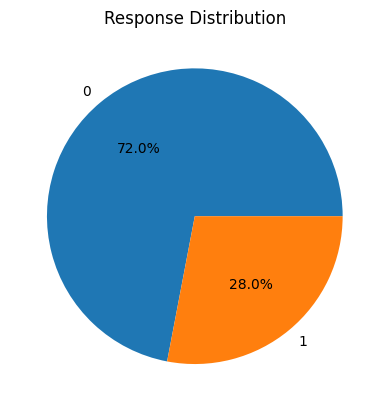

In [9]:
dataset['Response'].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Response Distribution")
plt.show()

Оценим распределение исследуемых по возрасту.

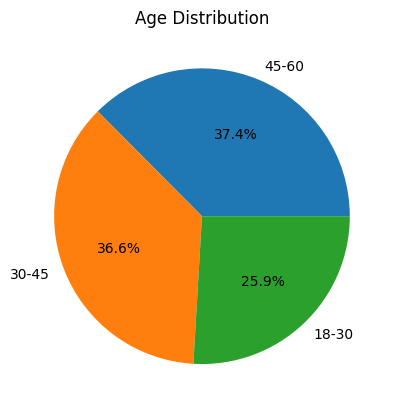

In [10]:
bins=[18,30,45,60]
labels=['18-30','30-45','45-60']
dataset['Age_group'] = pd.cut(dataset['Age'], bins=bins, labels=labels)

dataset['Age_group'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Age Distribution')
plt.show()

## Часть 2
### Задачи 2-5

Оценим распределение уровней биомаркеров до и после процедуры.

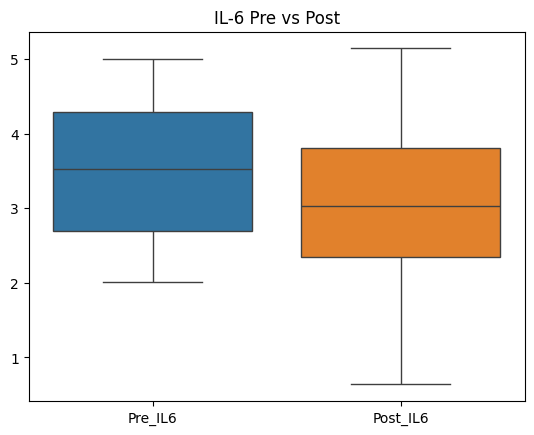

In [11]:
sns.boxplot(dataset[['Pre_IL6', 'Post_IL6']])
plt.title('IL-6 Pre vs Post')
plt.show()

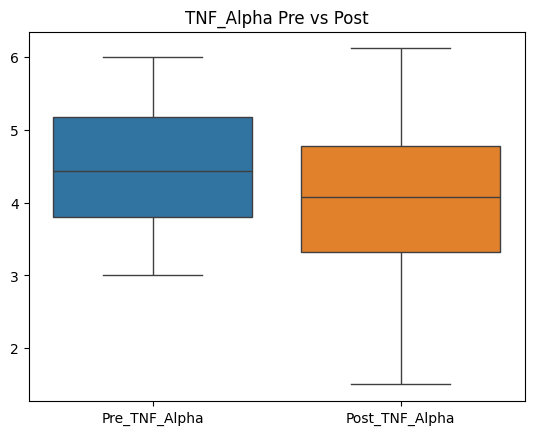

In [12]:
# Отредактируйте код для создания диаграмм Boxplot для показателей Pre_TNF_Alpha и Post_TNF_Alpha
sns.boxplot(dataset[['Pre_TNF_Alpha', 'Post_TNF_Alpha']])
plt.title('TNF_Alpha Pre vs Post')
plt.show()

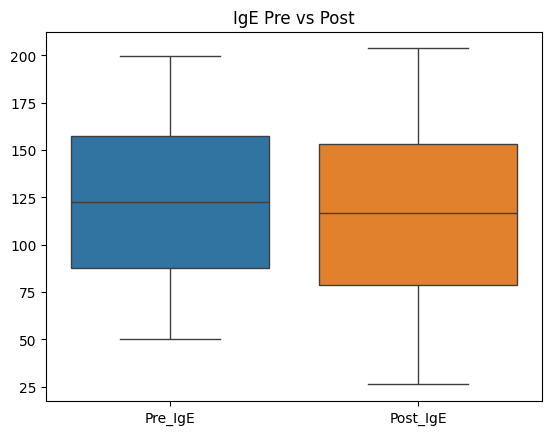

In [13]:
# Напишите код ниже для создания диаграмм Boxplot для показателей Pre_IgE и Post_IgE
sns.boxplot(dataset[['Pre_IgE', 'Post_IgE']])
plt.title('IgE Pre vs Post')
plt.show()

Оценим уровни биомаркеров у испытуемых, ответивших или не ответивших на проведение процедуры. Для этого используем диаграмму **Pairplot**, которая показывает при помощи точечных графиков распределение признака в различных группах.

По диагноли отображено распределение признака, в точечных графиках можно определить корреляцию признаков и применимость признаков для классификации групп (выделение предикторов, будет ли ответ на проведение манипуляции или нет), в случае, есои они формуируют оформленные кластеры или облока.

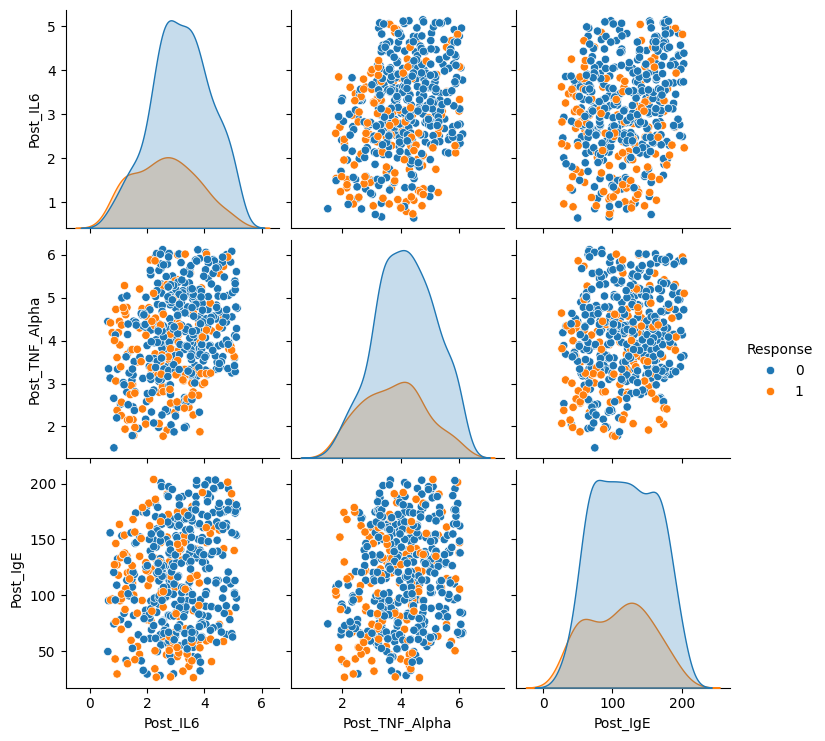

In [14]:
sns.pairplot(dataset[['Post_IL6', 'Post_TNF_Alpha', 'Post_IgE', 'Response']], hue='Response')
plt.show()

Оценим корреляцию признаков в датасете при помощи корреляционной матрицы **Heatmap**.

Здесь в ячейках матрицы указаны коэффициенты корреляции Пирсона, а цвет ячеек зависит от величины коэффициента.

Как интерпетировать коэффциент корреляции?

1. Смотрим на знак:
**Положительная (+) корреляция**: Обе величины меняются в одну сторону. Растет одна — растет и вторая (например, индекс массы тела и риск диабета).
**Отрицательная (-) корреляция**: Величины меняются в разные стороны. Растет одна — падает вторая (например, физическая активность и уровень холестерина).
2. Оцениваем абсолютное значение:
    
    0.0 - 0.3: Связь **слабая** или отсутствует. Клинического значения почти не имеет.
    
    0.3 - 0.7: Связь **умеренная**. Видна тенденция, которую стоит учитывать.
    
    0.7 - 0.9: Связь **сильная**. Величины очень плотно зависят друг от друга.
    
    0.9 - 1.0: Связь **очень сильная** (почти функциональная).

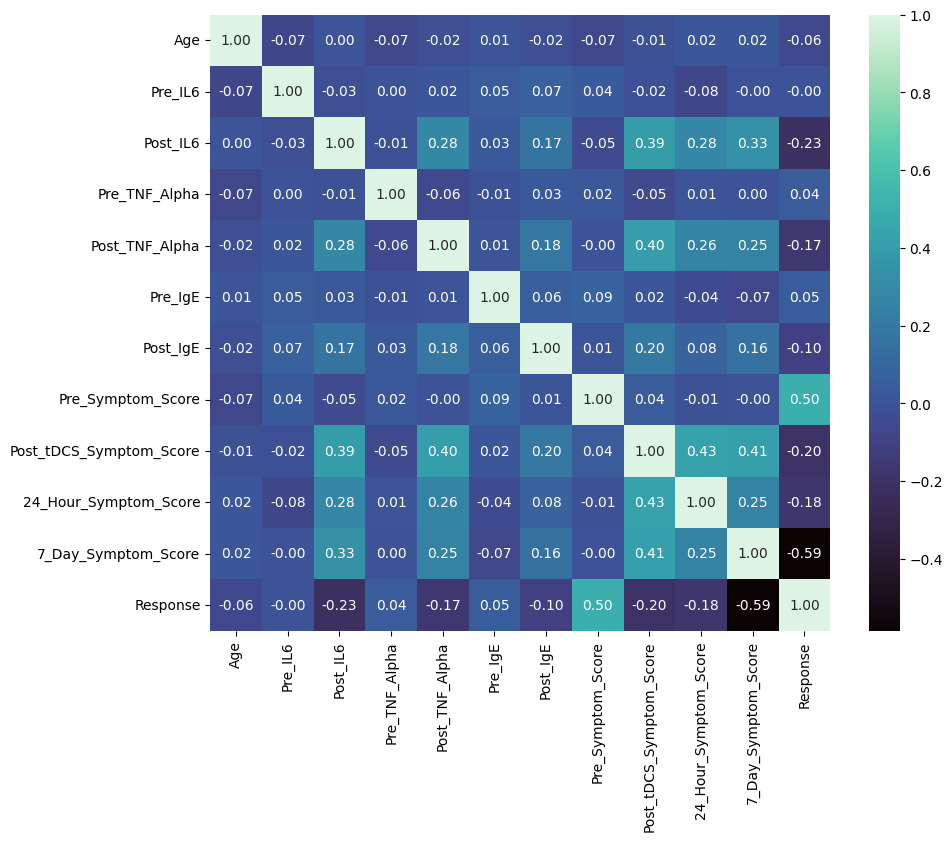

In [15]:
corr = dataset.drop(columns=['Current_mA', 'Duration_min']).corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="mako")
plt.show()

Оценим динамику симптомов у всех испытуемых.

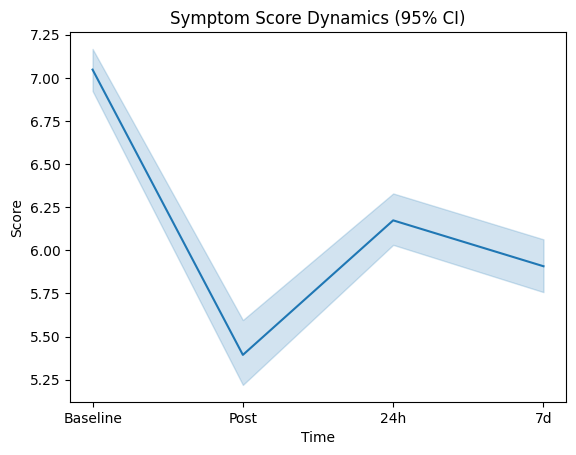

In [16]:
symptom_dataset = dataset[[
    'Pre_Symptom_Score',
    'Post_tDCS_Symptom_Score',
    '24_Hour_Symptom_Score',
    '7_Day_Symptom_Score'
]].copy()

symptom_dataset.columns = ['Baseline', 'Post', '24h', '7d']

long_dataset = symptom_dataset.melt(var_name='Time', value_name='Score')

sns.lineplot(data=long_dataset, x='Time', y='Score', errorbar=('ci', 95)) # Задаем отображение доверительных интервалов
plt.title('Symptom Score Dynamics (95% CI)')
plt.show()

По предудщему графику довольно сложно делать выводы о влиянии вмешательства на влияние симптомов. Давайте проанализируем динамику отдельно по группе вмешательство и группе плацебо.

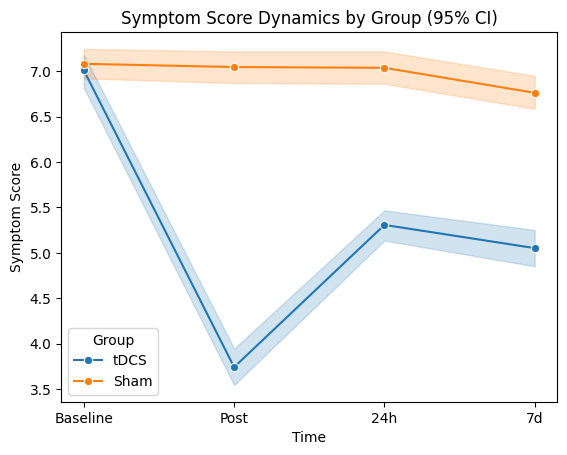

In [17]:
tdcs_dataset = dataset[dataset['Group'] == 'tDCS']
tdcs_symptom_dataset = tdcs_dataset[[
    'Pre_Symptom_Score',
    'Post_tDCS_Symptom_Score',
    '24_Hour_Symptom_Score',
    '7_Day_Symptom_Score'
]].copy()
tdcs_symptom_dataset.columns = ['Baseline', 'Post', '24h', '7d']
tdcs_long_dataset = tdcs_symptom_dataset.melt(var_name='Time', value_name='Score')

sham_dataset = dataset[dataset['Group'] == 'Sham']
sham_symptom_dataset = sham_dataset[[
    'Pre_Symptom_Score',
    'Post_tDCS_Symptom_Score',
    '24_Hour_Symptom_Score',
    '7_Day_Symptom_Score'
]].copy()
sham_symptom_dataset.columns = ['Baseline', 'Post', '24h', '7d']
sham_long_dataset = sham_symptom_dataset.melt(var_name='Time', value_name='Score')

tdcs_long_dataset['Group'] = 'tDCS'
sham_long_dataset['Group'] = 'Sham'

combined_symptom_dataset = pd.concat([tdcs_long_dataset, sham_long_dataset])

plt.figure()
sns.lineplot(data=combined_symptom_dataset, x='Time', y='Score', hue='Group', errorbar=('ci', 95), marker='o')
plt.title('Symptom Score Dynamics by Group (95% CI)')
plt.ylabel('Symptom Score')
plt.show()

## Часть 3
### Задачи 6-7

Расчитаем относительный риск (RR) для оценки эффективности вмешательства.

**Относительный риск** (Relative Risk, RR) — это показатель того, во сколько раз вероятность события (в нашем случае - улучшения симптомов АР) в одной группе выше, чем в другой. Это самый понятный способ оценить позитивный или негативный эффект фактора или всешательства.

Пошаговый алгоритм расчета RR:
1. Считаем вероятность улучшения в группе **вмешательства**:
*Количество пациентов с «1» (улучшение симптомов) делим на общее количество людей в этой группе.*
2. Считаем вероятность улучшения в группе **плацебо**:
*Количество пациентов с «1» в группе плацебо делим на общее количество людей в этой группе.*
3. Делим первое на второе.

Выведем таблицу с данными результирующего показателя по группам.

In [18]:
table = pd.crosstab(dataset['Group'], dataset['Response'])
print(table)

Response    0    1
Group             
Sham      211   39
tDCS      149  101


Выделим данные из этой таблицы и расчитаем относительный риск.

In [19]:
# Выделение данных
a = table.loc['tDCS', 1] # Группа вмешательство, с улучшением симптомов
b = table.loc['tDCS', 0] # Группа вмешательство, без улучшения симптомов
c = table.loc['Sham', 1] # Группа плацебо, с улучшением симптомов
d = table.loc['Sham', 0] # Группа плацебор, без улучшения симптомов

# Вероятность улучшения симптомов в группе вмешательства
risk_tdcs = a / (a + b)
# Вероятность улучшения симптомов в группе плацебо
risk_sham = c / (c + d)

# Относительный риск (RR)
RR = risk_tdcs / risk_sham
RR = round(RR, 3)
print("RR:", RR)

RR: 2.59


Расчет доверительных интервалов для относительного риска проводится несколько сложнее, чем для среднего значения, потому что распределение рисков несимметрично. Чтобы его посчитать, математики сначала переводят данные в логарифмы, а потом возвращают обратно.

На языке Python это будет выглядеть примерно так:

In [20]:
# Расчет CI для RR
se_log_RR = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d)) # Вычисление стандартной ошибки логарифма RR
ci_low = np.exp(np.log(RR) - 1.96 * se_log_RR)
ci_high = np.exp(np.log(RR) + 1.96 * se_log_RR)

ci_low = round(ci_low, 2)
ci_high = round(ci_high, 2)

print("RR:", RR, "95% CI:", ci_low, "-", ci_high)

RR: 2.59 95% CI: 1.87 - 3.59


In [21]:
# Разница вероятностей
ARR = round(risk_tdcs - risk_sham, 2)

# Number Needed to Treat (NNT)
NNT = round(1 / ARR, 2)

print("Снижение абсолютного риска:", ARR, "Число больных для получения 1-го положительного результата:", NNT)

Снижение абсолютного риска: 0.25 Число больных для получения 1-го положительного результата: 4.0


In [22]:
def rr(df):
    table = pd.crosstab(df['Group'], df['Response'])
    print(table)
    # Выделение данных
    a = table.loc['tDCS', 1] # Группа вмешательство, с улучшением симптомов
    b = table.loc['tDCS', 0] # Группа вмешательство, без улучшения симптомов
    c = table.loc['Sham', 1] # Группа плацебо, с улучшением симптомов
    d = table.loc['Sham', 0] # Группа плацебор, без улучшения симптомов

    # Вероятность улучшения симптомов в группе вмешательства
    risk_tdcs = a / (a + b)
    # Вероятность улучшения симптомов в группе плацебо
    risk_sham = c / (c + d)

    # Относительный риск (RR)
    RR = risk_tdcs / risk_sham
    RR = round(RR, 3)

    # Расчет CI для RR
    se_log_RR = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d)) # Вычисление стандартной ошибки логарифма RR
    ci_low = np.exp(np.log(RR) - 1.96 * se_log_RR)
    ci_high = np.exp(np.log(RR) + 1.96 * se_log_RR)

    ci_low = round(ci_low, 2)
    ci_high = round(ci_high, 2)

    print("RR:", RR, "95% CI:", ci_low, "-", ci_high)
    return RR, ci_low, ci_high

In [23]:
dataset_1830 = dataset[dataset["Age_group"] == '18-30']
RR_1830, ci_low_1830, ci_high_1830 = rr(dataset_1830)

Response   0   1
Group           
Sham      48  12
tDCS      38  28
RR: 2.121 95% CI: 1.19 - 3.78


In [24]:
dataset_3045 = dataset[dataset["Age_group"] == '30-45']
RR_3045, ci_low_3045, ci_high_3045 = rr(dataset_3045)

Response   0   1
Group           
Sham      79  13
tDCS      47  39
RR: 3.209 95% CI: 1.84 - 5.59


In [25]:
dataset_4560 = dataset[dataset["Age_group"] == '45-60']
RR_4560, ci_low_4560, ci_high_4560 = rr(dataset_4560)

Response   0   1
Group           
Sham      78  12
tDCS      62  30
RR: 2.446 95% CI: 1.34 - 4.47


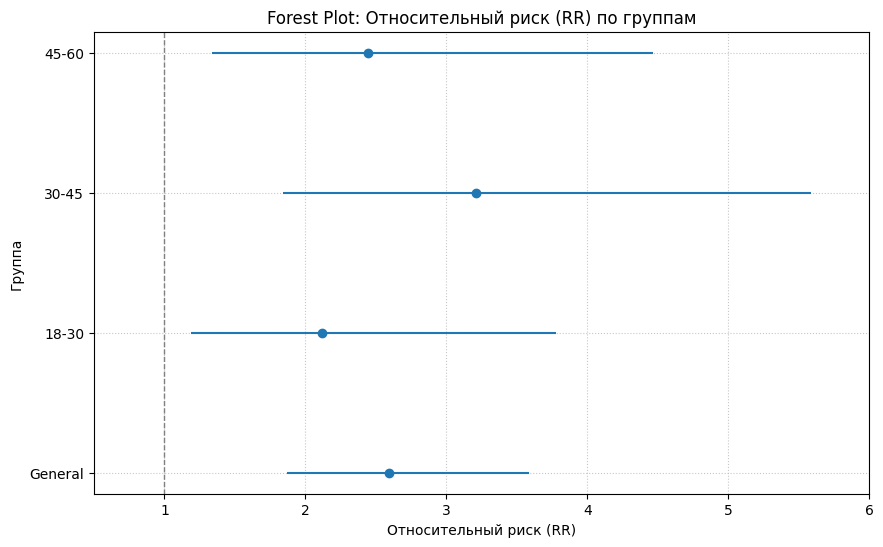

In [26]:
data = {
    'Group': ['General', '18-30', '30-45', '45-60'],
    'RR': [RR, RR_1830, RR_3045, RR_4560],
    'Lower CI': [ci_low, ci_low_1830, ci_low_3045, ci_low_4560],
    'Upper CI': [ci_high, ci_high_1830, ci_high_3045, ci_high_4560]
}
df_forest = pd.DataFrame(data)
df_forest
plt.figure(figsize=(10, 6))
ax = plt.gca()

x_err_lower = df_forest['RR'] - df_forest['Lower CI']
x_err_upper = df_forest['Upper CI'] - df_forest['RR']
x_err = [x_err_lower, x_err_upper]

ax.errorbar(x=df_forest['RR'],
            y=range(len(df_forest)),
            xerr=x_err,
            fmt='o',
            )

ax.axvline(x=1.0, color='gray', linestyle='--', linewidth=1)

ax.set_yticks(range(len(df_forest)))
ax.set_yticklabels(df_forest['Group'])

plt.xlabel('Относительный риск (RR)')
plt.ylabel('Группа')
plt.title('Forest Plot: Относительный риск (RR) по группам')

plt.xlim(0.5, 6.0)

plt.grid(True, linestyle=':', alpha=0.7)
plt.show()